**Задача**

1) Создать синтетический набор данных используя открытую LLM для решения поставленной задачи

2) Обучить модель классификации текста на основе созданного набора данных используя трансформерную модель энкодер (например BERT)

**Генерация данных**

Требования к данным:  

1)Набор даных должен представлять диалоги клиентов с поддержкой на тему банковских услуг (кредиты, денжные переводы и т.д).

2)Набор данных должен быть создан для решения задачи классификации последнего сообщения пользователя в диалоге - (класс - текущий вопрос пользователя по которому будет выдаваться некоторые заранее заготовленный ответ)

3)В Наборе данных должно быть не менее 15 классов (больше можно), выполняющий имеет свободу выбора сам составить предполагаемые классы сообщений или же сгенерировать их. Для каждого класса нужно сгенерировать не менее 20 различны примеров для обучения и 10 для теста.

4) Формат данных:

{"label": 'transfer_status',

"dialog":

"user: Привет! можете помочь мне ?

assistant: Здравствуйте! В чем ваш вопрос?

user: Мой перевод все еше не пришел, какой у него cтатус ?"}

5) Напоминание, класс определяется именно для последнего сообщения в контексте диалога, а не для последнего сообщения в отдельности или же диалога в целом.

**Обучение классификатора**

1) Достаточный вариант - реализовать обучение через Trainer из huggingface transformers, на портале есть множество гайдов в том числе для решения задачи классификации текста с помощью моделей энкодеров (например BERT)

2)При желании можно показать свои навыки в написании кастомных циклов обучения, не используя готовый класс Trainer

3)Желательно использовать transformers + pytorch, другие варианты (например через tensorflow также будут проверяться, но этот фреймворк редко используется в практике проверяющих)

## Подготовка окружения

Для загрузки модели из Hugging Face используется токен,
который хранится в секретах Google Colab.

В качестве генератора синтетических данных используется
`IlyaGusev/saiga_llama3_8b_gguf`.

Используется квантованная версия модели `Q8_0`, что позволяет
запустить генерацию локально в среде Google Colab и не использовать внешний API.

Модель используется только для создания датасета.
Для последующей классификации используется отдельная
encoder-модель.

In [1]:
from google.colab import userdata
from huggingface_hub import login

login(userdata.get('HF_TOKEN'))

In [2]:
from huggingface_hub import snapshot_download

model_name = "IlyaGusev/saiga_llama3_8b_gguf"
base_model = "./original/"
snapshot_download(repo_id=model_name, local_dir=base_model, ignore_patterns=["*.pth"],allow_patterns="model-q8_0.gguf")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'/content/original'

### Подготовка локального запуска LLM

Для запуска GGUF-модели используется `llama.cpp` и библиотека
`llama-cpp-python`.

После загрузки модели выполняется её инициализация с использованием GPU.

In [3]:
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cu122
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 GB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.5 MB/s eta 0:00:00


In [11]:
from llama_cpp import Llama
import llama_cpp

In [5]:
llm = Llama(model_path="./original/model-q8_0.gguf", n_gpu_layers=-1, verbose=False)

# Генерация синтетических данных

На этом этапе создается датасет для обучения классификатора.

Для каждого класса LLM получает отдельный промпт, содержащий
описание требуемого намерения пользователя.

LLM должна сформировать диалог из трех реплик:

`user → assistant → user`

Последняя реплика должна соответствовать заданному классу.

После генерации ответ модели дополнительно проверяется:

- является ли результат корректным JSON;
- присутствуют ли необходимые поля;
- соответствует ли label требуемому классу;
- начинается ли диалог с сообщения `user`;
- корректно ли сохранен текст диалога.

Некорректные ответы не попадают в датасет и генерируются повторно.

In [6]:
import json
import re
MAX_LENGTH = 250
classes = [
    "блокировка или разблокировка карты",
    "баланс или остаток на счете",
    "условия получения нового кредита",
    "досрочное погашение кредита",
    "статус отправленного перевода",
    "комиссии и лимиты на переводы",
    "оспаривание транзакции и чарджбэк",
    "правила начисления кэшбэка и бонусов",
    "восстановление или смена пароля",
    "увеличение лимита по кредитной карте",
    "инвестиции и ценные бумаги",
    "актуальный курс валют",
    "заказ справок и выписок по счету",
    "условия открытия вклада или счета",
    "сообщения о мошенничестве и безопасность"
]
def save_batch(raw_text, filename,labe):
# Проверяем ответ LLM перед добавлением в датасет
#LLM может вернуть некорректный JSON или изменить название класса поэтому перед сохранением выполняется несколько проверок
    try:
        star_ind = raw_text.find('{')
        end_ind = raw_text.rfind('}') + 1
        json_str = re.sub(r'"\s*\+\s*"', '', raw_text[star_ind:end_ind])
        json_str = re.sub(r'("(?:\\.|[^"\\])*")', lambda m: m.group(1).replace('\n', '\\n').replace('\r', '\\r'), json_str)
        data = json.loads(json_str)
        dialog_content = data.get("dialog", "")
        data["label"] = data["label"].lower()
        if data["label"] != labe:
          raise Exception
        if isinstance(dialog_content, list):
            data["dialog"] = "\n".join(dialog_content)
        if not dialog_content.strip().startswith("user:"):
            raise Exception
        #ЗАпись
        with open(filename, 'a', encoding='utf-8') as f:
            f.write(json.dumps(data, ensure_ascii=False) + '\n')
        return 1
    except:
        print("Ошибка генерации")
        return 0
# Формируем инструкцию для LLM
# Важно явно указать структуру диалога и целевой класс
#чтобы последнее сообщение пользователя соответствовало именно требуемому намерению
def generate_dialog(classes,classes_config):

  for label in classes:
    i = 0
    while i != classes_config[1]:

        prompt =f"""Ты эксперт по созданию обучающих данных. Твоя задача — написать ролевой диалог между клиентом банка (user) и оператором поддержки (assistant).

        ПРАВИЛА ПОСТРОЕНИЯ ДИАЛОГА (ровно 3 реплики) диалог должен подводить к теме {label}:
        1. Реплика 1 (user): Клиент банка обращается с вопросом подводящим к теме {label} или просто начинает разговор.
        2. Реплика 2 (assistant): Оператор банка отвечает или задает уточняющий вопрос.
        3. Реплика 3 (user): Клиент банка задает свой главный вопрос, который соответствует теме "{label}".
        Если assistnt задал вопрос user должен ответить и только после этого задать вопрос по теме "{label}".
        Формат ответа — строго JSON объект:
        {{"label": "{label}", "dialog": "\\nuser: текст\\nassistant: текст\\nuser: финальный вопрос {label}" [END]}}
        Пиши только JSON, без лишних вступлений."""
        # Параметры генерации.
        # Умеренная temperature позволяет получать разные формулировки
        # сохраняя при этом соответствие заданному классу
        generation_kwargs = {
            "max_tokens": MAX_LENGTH,
            "temperature": 0.5,
            "top_k": 40,
            "top_p": 0.9,
            "repeat_penalty": 1.25,
            "stop":["}","[END]"]
        }

        res = llm(prompt, **generation_kwargs)
        r = res['choices'][0]['text'] + "}"
        if save_batch(r,classes_config[0],label):
          i+=1
          print(f"Сгенерировано {i} диалогов из {classes_config[1]} на тему {label}")
classes_config = {
    'train.jsonl': 20,
    'validation.jsonl': 10,
    'test.jsonl': 10
}
for classes_config in classes_config.items():
    generate_dialog(classes, classes_config)

Сгенерировано 1 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 2 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 3 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 4 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 5 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 6 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 7 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 8 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 9 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 10 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 11 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 12 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 13 диалогов из 20 на тему блокировка или разблокировка карты
Сгенерировано 14 диалогов из 20 на

In [7]:
#Отображение примера одного диалога для каждого класса
import pandas as pd
df = pd.read_json('train.jsonl', lines=True)
result = df.drop_duplicates('label')
for index, row in result.iterrows():
    print(f"Класс: {row['label']}")
    print(row['dialog'])
    print("-" * 60)

Класс: блокировка или разблокировка карты

user: Привет, у меня возник вопрос по карте. Я не могу использовать её в магазине.
assistant: Извините за беспокойство! Пожалуйста, уточните, когда именно вы последний использовали эту карту и были ли все ваши транзакции успешными?
user: Это было вчера вечером около 9 часов. Всё шло нормально до тех пор пока я не попробовал в магазине.

------------------------------------------------------------
Класс: баланс или остаток на счете

user: Какой баланс у меня в банке?
assistant: Для узнать ваш текущий баланс, пожалуйста, предоставьте номер карты.
user: Есть ли возможность перевести деньги со своего счёта?
------------------------------------------------------------
Класс: условия получения нового кредита

user: Привет, я хотел бы узнать о новых кредитных программах и условиях их предоставления.
assistant: Спасибо за интерес в нашем банке. Какой именно вид кредита вас интересует? (ипотека, потребительский или бизнес)?
user: У меня есть небольшое 

# Подготовка выборок

Полученные данные разделены на три части:

- `train` - используется для обучения модели;
- `validation` - используется для контроля обучения и выбора
  лучшей версии модели;
- `test` - используется только один раз после завершения обучения
  для получения финальной оценки.

Всего:

- train: 300 примеров;
- validation: 150 примеров;
- test: 150 примеров.

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

MODEL_NAME = "cointegrated/rubert-tiny2"
OUTPUT_DIR = "./results"
SAVE_PATH = "./best_bank_intent_model"
NUM_LABELS = len(classes)

def load_data(file_path):
    # Загружаю сохранённый JSONL-файл построчно
    # Каждая строка содержит один диалог и его целевой класс
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    # Преобразую список объектов в Dataset,совместимый с библиотекой Hugging Face
    ds = Dataset.from_list(data)
    #Энкодинг классов
    return ds.class_encode_column("label")

def compute_metrics(eval_pred):
    # Метрики
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)#Accuracy показывает долю правильно классифицированных диалогов
    f1 = f1_score(labels, predictions, average='weighted')#F1 показывает гармоническое среднее между Precision и Recall
    return {"accuracy": acc, "f1": f1}
def train():
    #Загрузка данных и токенизатора
    dataset_train = load_data("train.jsonl")
    dataset_validation = load_data("validation.jsonl")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_fn(batch):
        return tokenizer(batch["dialog"], padding="max_length", truncation=True, max_length=MAX_LENGTH)
    #Токенизация диалогов
    tokenized_train = dataset_train.map(tokenize_fn, batched=True)
    tokenized_validation = dataset_validation.map(tokenize_fn,batched=True)

    #Загружаем предварительно обученную encoder-модель RuBERT
    #num_labels определяет количество классов,которым модель должна научиться соответствовать.#Инициализация модели
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

    # параметры обучения классификатора модель обучается на train-выборке, а после каждой эпохи оценивается на validation-выборке
    #при достижении лучшего результата модель сохраняется а EarlyStopping позволяет остановить обучение если качество на validation перестаёт улучшаться.
    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-5,
        num_train_epochs=60,
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        weight_decay=0.001,
        save_only_model=True,
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_validation,
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    #Сохраняю лучшую модель
    trainer.save_model(SAVE_PATH)
    #Вместе с моделью сохраняю токенизатор
    tokenizer.save_pretrained(SAVE_PATH)

    return trainer.state.log_history
# В history сохраняются результаты обучения после каждой эпохи
history_data = train()



Casting to class labels:   0%|          | 0/300 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/150 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

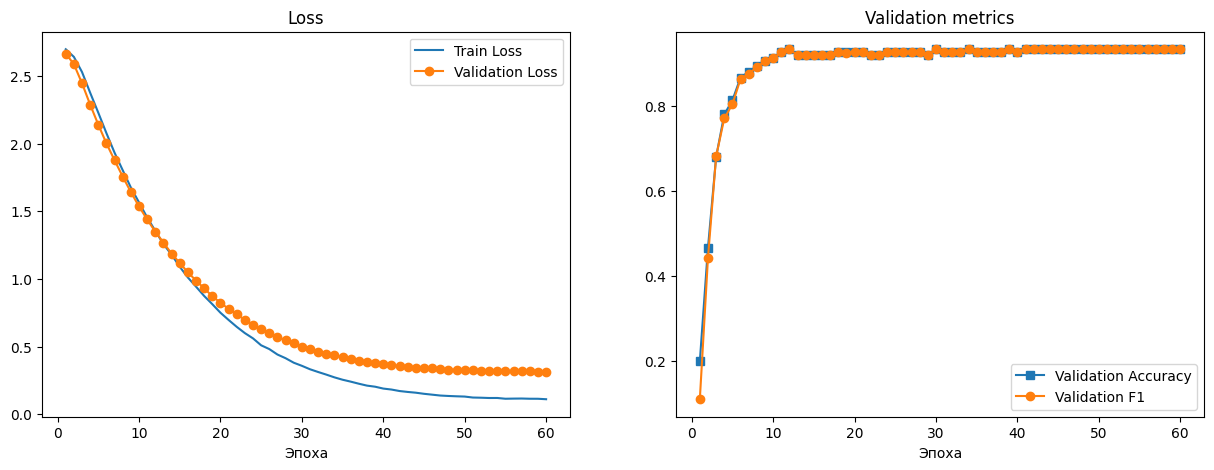

In [9]:

def plot_history(history):
    train_logs = [x for x in history if "loss" in x]
    eval_logs = [x for x in history if "eval_loss" in x]

    train_epochs = [x["epoch"] for x in train_logs]
    train_loss = [x["loss"] for x in train_logs]

    eval_epochs = [x["epoch"] for x in eval_logs]
    eval_loss = [x["eval_loss"] for x in eval_logs]
    eval_acc = [x["eval_accuracy"] for x in eval_logs]
    eval_f1 = [x["eval_f1"] for x in eval_logs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    #Первый график показывает изменение ошибки обучения
    #Сравнение train и validation loss позволяет оценить,не начинает ли модель переобучаться
    ax1.plot(train_epochs,train_loss,label="Train Loss")
    ax1.plot(eval_epochs,eval_loss,label="Validation Loss",marker="o"
    )
    ax1.set_title("Loss")
    ax1.set_xlabel("Эпоха")
    ax1.legend()

    #Второй график показывает качество классификации на validation-выборке по двум метрикам Accuracy и F1
    ax2.plot(eval_epochs,eval_acc,label="Validation Accuracy",marker="s")
    ax2.plot(eval_epochs,eval_f1,label="Validation F1",marker="o")
    ax2.set_title("Validation metrics")
    ax2.set_xlabel("Эпоха")
    ax2.legend()
    plt.show()


plot_history(history_data)

# Финальная оценка модели

После завершения обучения модель проверяется на test-выборке,
которая не использовалась во время обучения и выбора лучшей модели.

На этом этапе рассчитываются:

- Accuracy - доля правильных предсказаний;
- F1 - итоговая F1-метрика;
- Classification Report - подробные метрики для каждого класса;
- Confusion Matrix - матрица ошибок, показывающая, какие классы
  модель чаще всего путает между собой.

Casting to class labels:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Детальные метрики по каждому классу:
                                          precision    recall  f1-score   support

                   актуальный курс валют     1.0000    1.0000    1.0000        10
             баланс или остаток на счете     1.0000    0.9000    0.9474        10
      блокировка или разблокировка карты     1.0000    1.0000    1.0000        10
         восстановление или смена пароля     1.0000    1.0000    1.0000        10
             досрочное погашение кредита     0.8182    0.9000    0.8571        10
        заказ справок и выписок по счету     1.0000    1.0000    1.0000        10
              инвестиции и ценные бумаги     1.0000    1.0000    1.0000        10
           комиссии и лимиты на переводы     1.0000    0.7000    0.8235        10
       оспаривание транзакции и чарджбэк     0.9000    0.9000    0.9000        10
    правила начисления кэшбэка и бонусов     1.0000    0.9000    0.9474        10
сообщения о мошенничестве и безопасность     1.0000    1.000

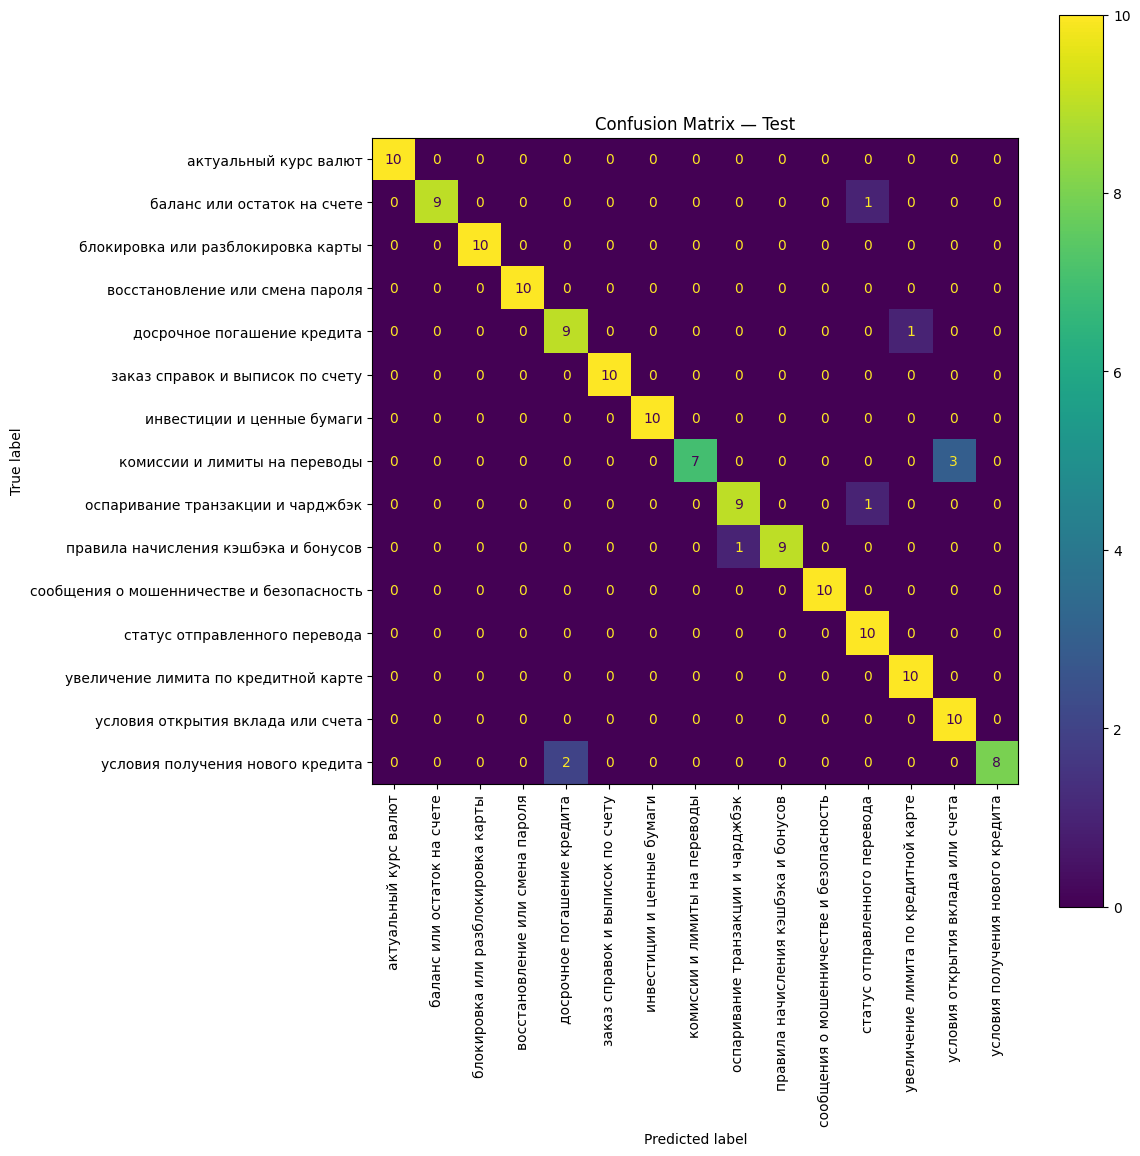

In [10]:
dataset_test = load_data("test.jsonl")
#Загружаю токенизатор из директории сохранённой модели,чтобы обработка test-данных полностью соответствовала
#обработке данных во время обучения
tokenizer = AutoTokenizer.from_pretrained(SAVE_PATH)

def tokenize_fn(batch):
    return tokenizer(
        batch["dialog"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_test = dataset_test.map(
    tokenize_fn,
    batched=True
)
#загружаю сохранённую лучшую версию классификатора
model = AutoModelForSequenceClassification.from_pretrained(
    SAVE_PATH
)
test_trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)
#получаю предсказания модели для всех тестовых примеров
preds = test_trainer.predict(tokenized_test)

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=-1)
target_names = dataset_test.features["label"].names
#формирую подробный отчёт по каждому классу
report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
)

print("Детальные метрики по каждому классу:")
print(report)
#рассчитываю итоговые метрики на test-выборке эти значения являются финальной оценкой качества обученного классификатора
test_metrics = {
    "test_accuracy": accuracy_score(y_true, y_pred),
    "test_f1": f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
}

print("\nФинальные метрики TEST:")

#визуализируем матрицу ошибок чтобы наглядно увидеть качество классификации каждого из 15 банковских intent-классов.
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")
    cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(12, 12))

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

ax.set_title("Confusion Matrix - Test")
plt.tight_layout()
plt.show()

# Итог
В рамках тестового задания был реализован полный цикл обработки банковских обращений: от автоматической генерации синтетического датасета с использованием открытой LLM до обучения и оценки модели классификации текстовых диалогов.

На первом этапе с помощью LLM были сгенерированы диалоги пользователей и банковского ассистента для 15 различных банковских тем. Полученные данные были дополнительно проверены по формату и соответствию заданному классу, после чего сформированы обучающая, валидационная и тестовая выборки. Таким образом, была подготовлена база для последующего обучения классификатора.
На втором этапе была обучена модель на основе rubert-tiny2, предназначенная для определения класса по последнему сообщению пользователя в диалоге.

В результате тестового задания удалось получить рабочую модель классификации банковских обращений на 15 классов. Модель достаточно быстро научилась различать основные типы запросов: уже к 10-й эпохе качество на validation-выборке достигло примерно 91% Accuracy и 91% F1, после чего показатели стабилизировались на уровне около 93%. При этом validation loss продолжал постепенно снижаться, что показывает дальнейшее улучшение уверенности модели без резкого ухудшения качества на отложенных данных.

На независимой тестовой выборке модель получила Accuracy = 94% и Weighted F1 = 93.97%. Это означает, что из 150 тестовых диалогов модель правильно классифицировала 141. Высокое качество на независимых тестовых данных, близкое к показателям на validation-выборке (около 93%), говорит о том, что модель не просто запомнила обучающие примеры, а смогла выучить устойчивые признаки, характерные для различных банковских намерений. Таким образом, существенного разрыва между качеством на validation- и test-выборках не наблюдается, что косвенно свидетельствует об отсутствии выраженного переобучения и о хорошей способности модели к обобщению.

Лучше всего модель справилась с классами, связанными с курсом валют, блокировкой карты, восстановлением пароля, справками и выписками, инвестициями и вопросами безопасности - для этих классов F1 достиг 1.00. Наибольшие сложности возникли с близкими по смыслу банковскими запросами: «комиссии и лимиты на переводы» (F1 = 0.8235), «досрочное погашение кредита» (0.8571), «условия открытия вклада или счета» (0.8696) и «условия получения нового кредита» (0.8889).

Таким образом, полученный результат можно считать хорошим для поставленной задачи: модель уверенно классифицирует большинство обращений, а оставшиеся ошибки в основном связаны с пересекающимися темами банковских услуг.
